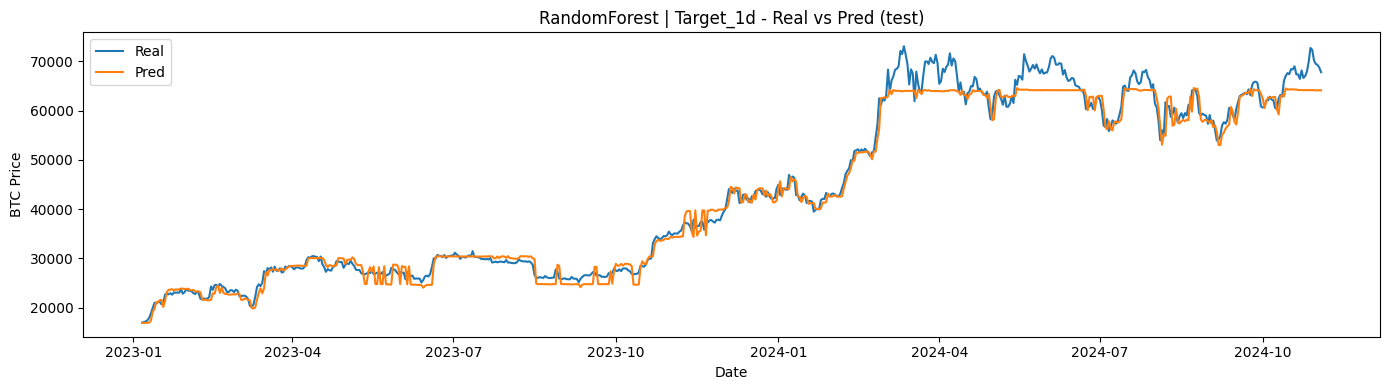

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/RandomForest_Target_1d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_RandomForest_Target_1d.png



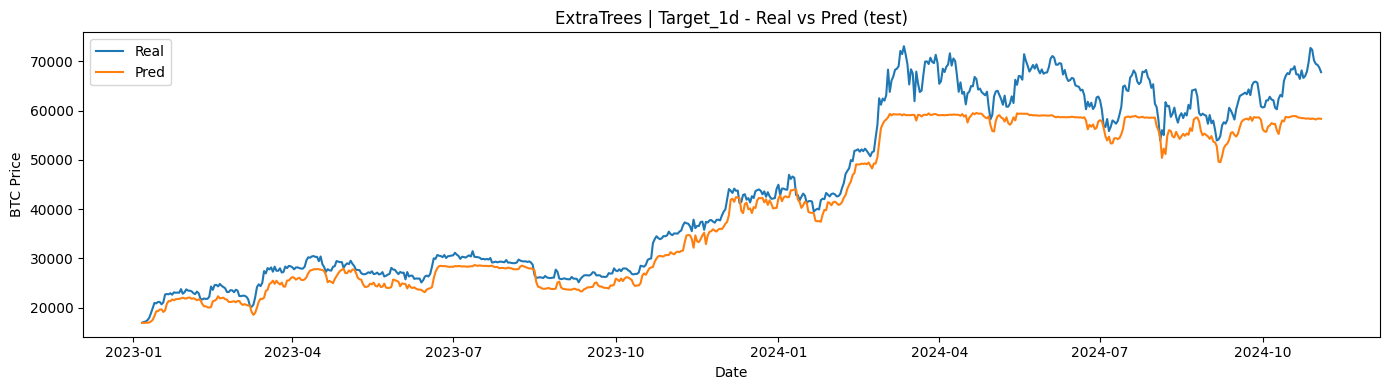

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/ExtraTrees_Target_1d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_ExtraTrees_Target_1d.png



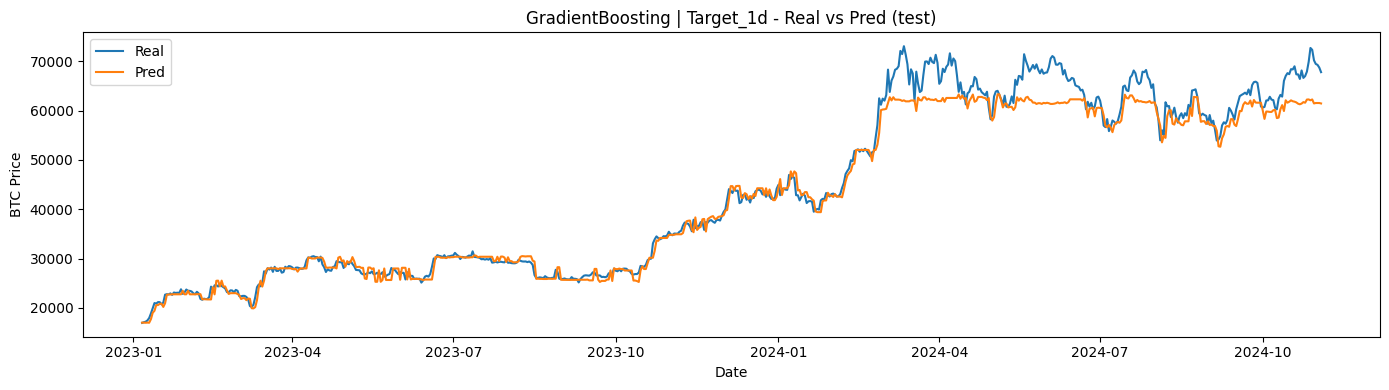

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/GradientBoosting_Target_1d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_GradientBoosting_Target_1d.png



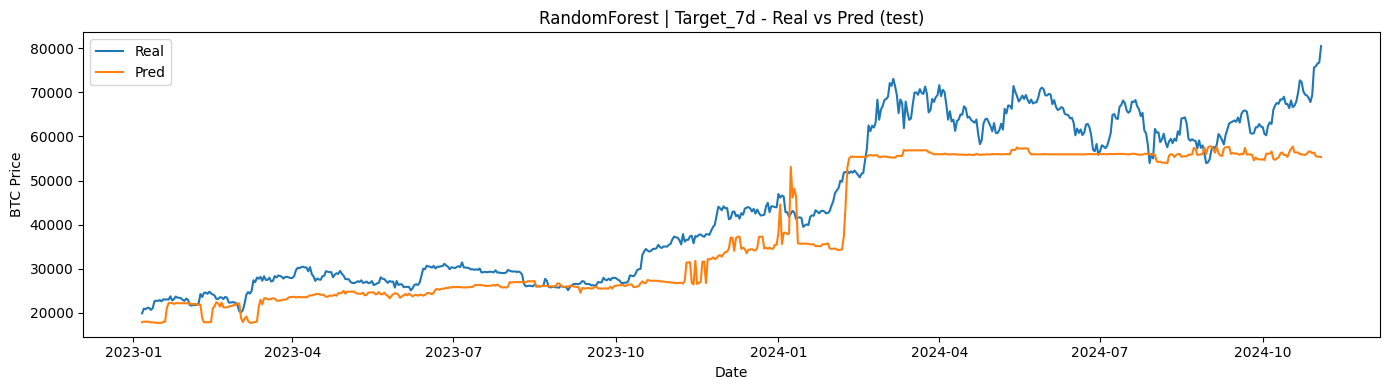

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/RandomForest_Target_7d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_RandomForest_Target_7d.png



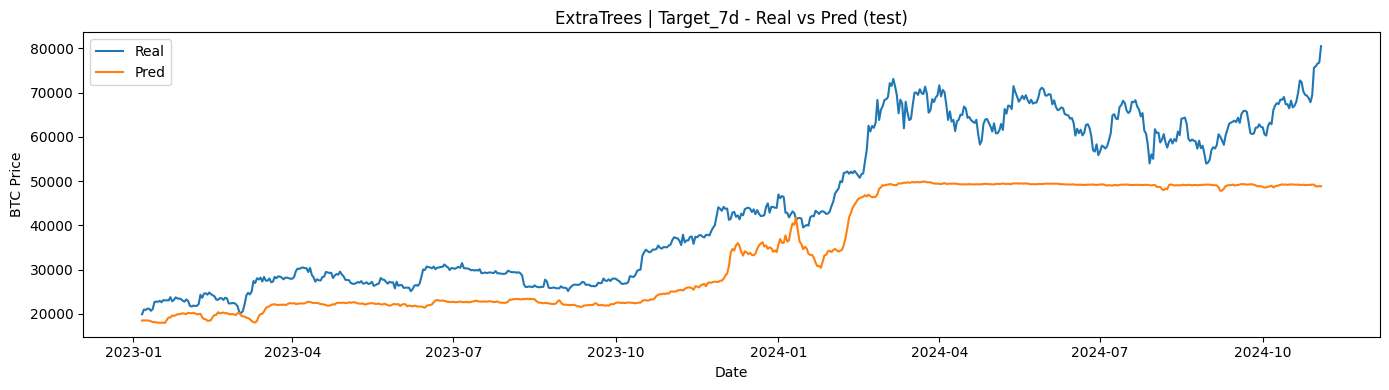

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/ExtraTrees_Target_7d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_ExtraTrees_Target_7d.png



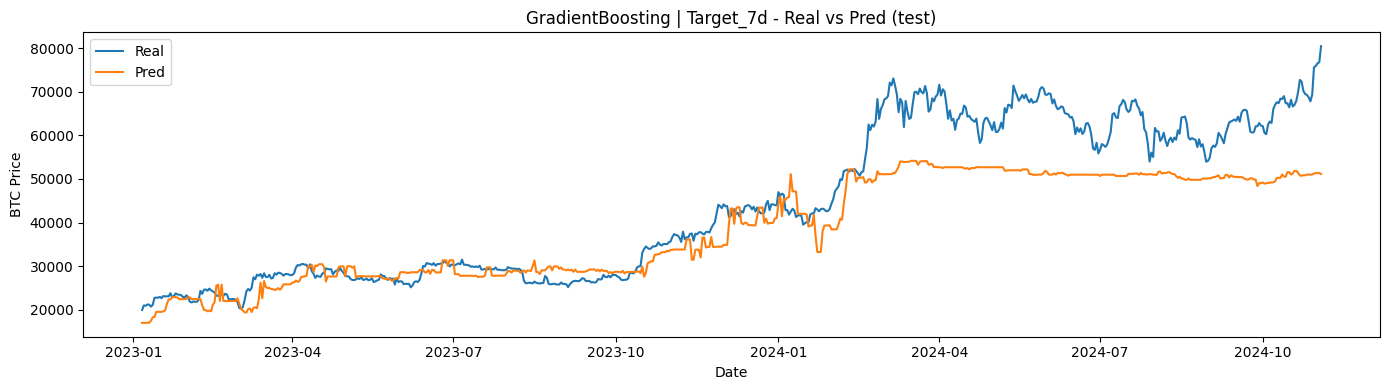

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/GradientBoosting_Target_7d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_GradientBoosting_Target_7d.png



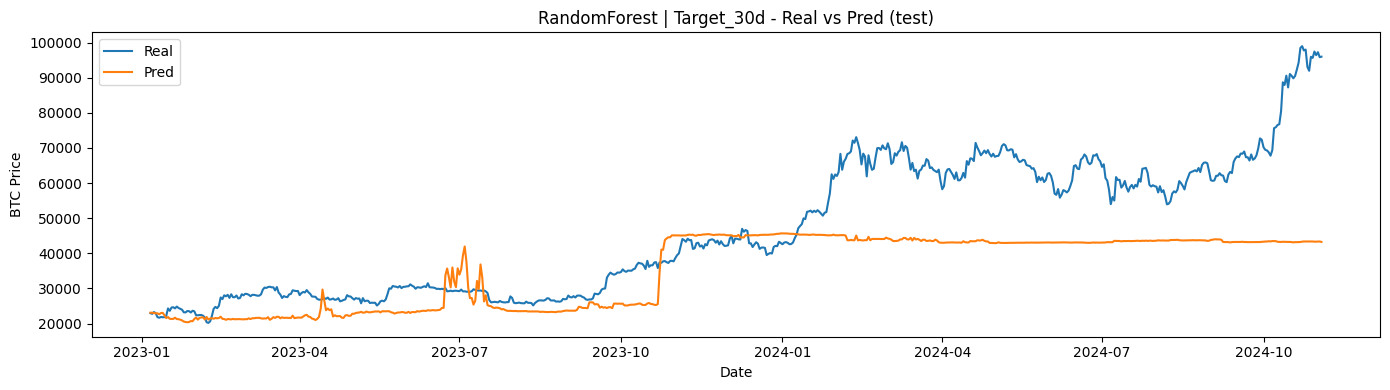

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/RandomForest_Target_30d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_RandomForest_Target_30d.png



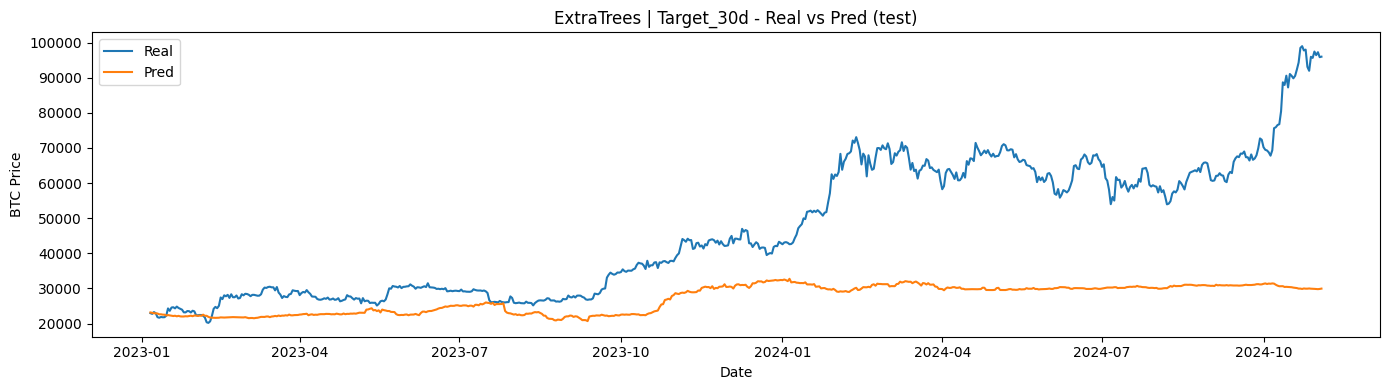

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/ExtraTrees_Target_30d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_ExtraTrees_Target_30d.png



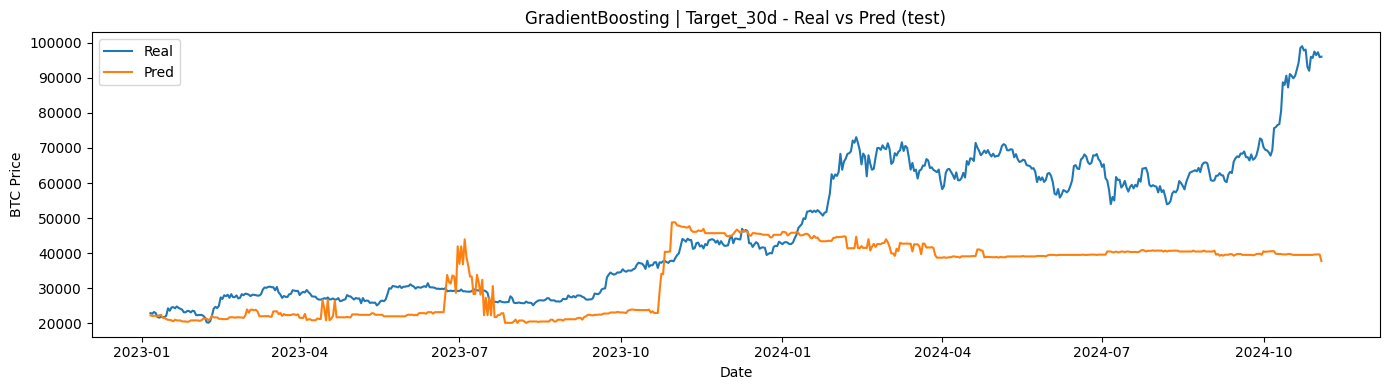

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/GradientBoosting_Target_30d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_GradientBoosting_Target_30d.png



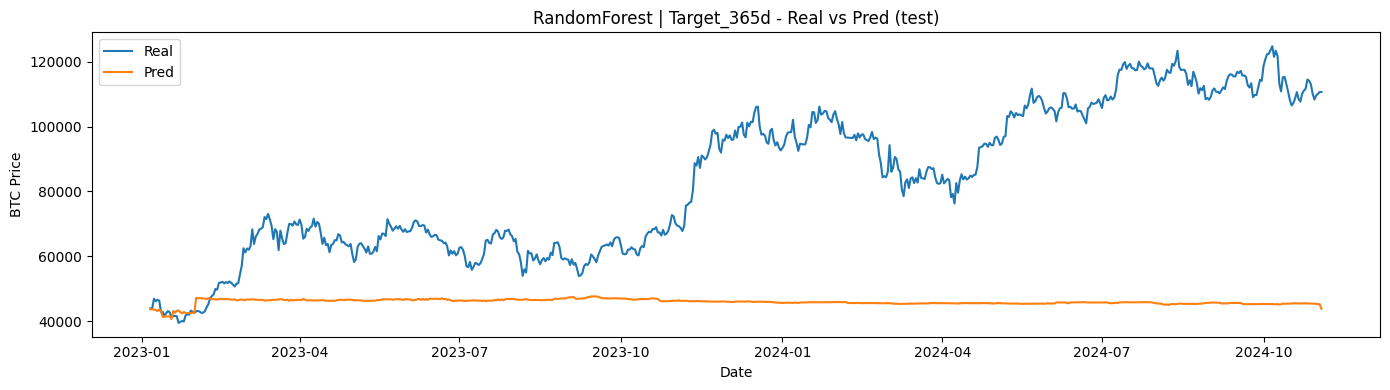

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/RandomForest_Target_365d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_RandomForest_Target_365d.png



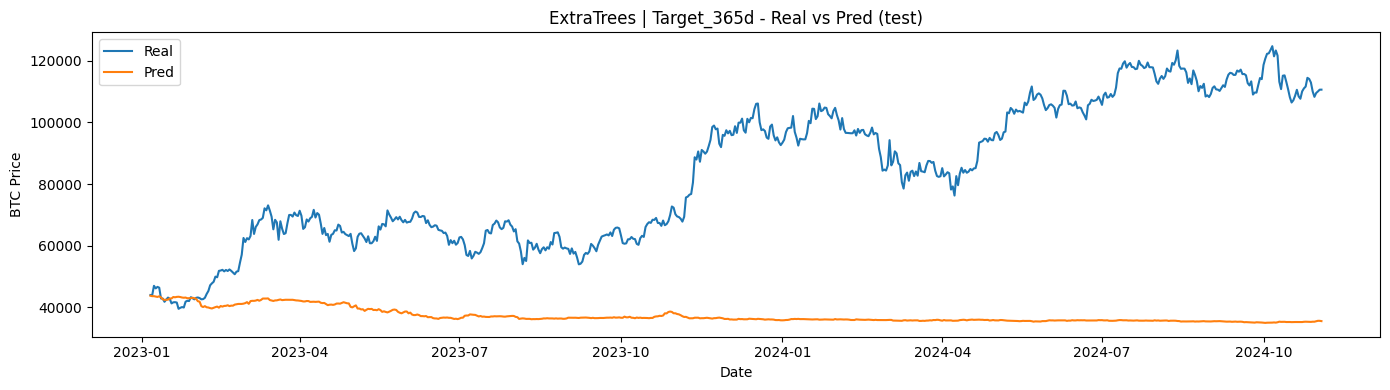

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/ExtraTrees_Target_365d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_ExtraTrees_Target_365d.png



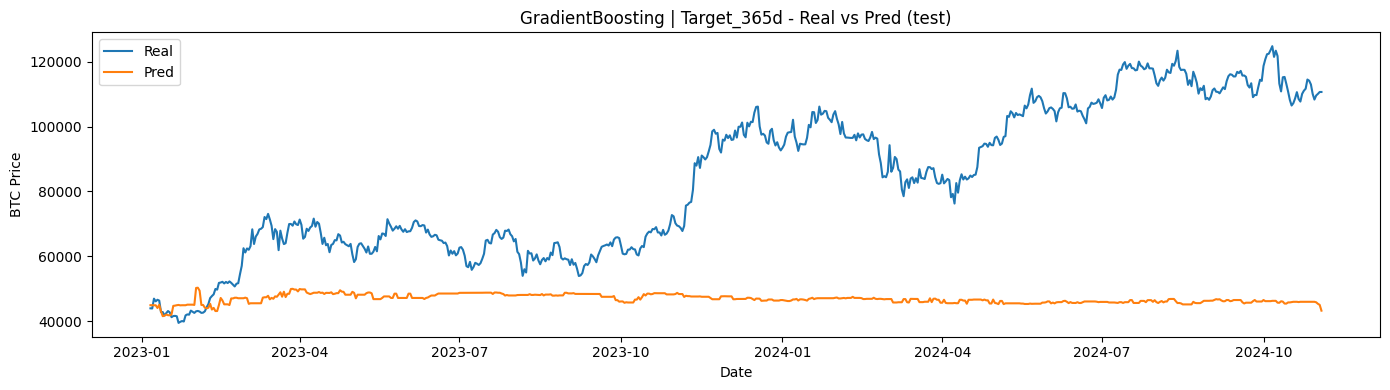

✅ Saved model: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/GradientBoosting_Target_365d.joblib
✅ Saved plot : /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/plot_GradientBoosting_Target_365d.png

✅ Murat advanced results saved: /content/drive/MyDrive/Bitcoin Price Prediction Project/results_advanced_murat.csv


,Target,Model,RMSE,MAE,R2,MAPE_%,Num_Features
0,Target_1d,RandomForest,2268.985902,1612.704509,0.982843,3.611055,112
2,Target_1d,GradientBoosting,2948.226589,1867.259140,0.971033,3.605462,112
1,Target_1d,ExtraTrees,4861.927075,3894.552139,0.921223,8.354136,112
6,Target_30d,RandomForest,16817.746700,12489.246829,0.225757,22.734712,112
8,Target_30d,GradientBoosting,18893.084355,14317.264177,0.022881,26.392811,112
7,Target_30d,ExtraTrees,25349.677935,19645.955860,-0.759083,34.928123,112
11,Target_365d,GradientBoosting,43329.549113,36749.365318,-2.600136,39.362779,112
9,Target_365d,RandomForest,43968.022969,37574.422191,-2.707016,40.411667,112
10,Target_365d,ExtraTrees,52277.998037,46253.805065,-4.240690,51.004408,112
3,Target_7d,RandomForest,7334.324745,6022.054680,0.822455,13.127305,112


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
import joblib

# 0) PATH
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_with_lags.csv"
OUT_DIR   = "/content/drive/MyDrive/Bitcoin Price Prediction Project"
OUT_PATH  = os.path.join(OUT_DIR, "results_advanced_murat.csv")

MODELS_DIR = os.path.join(OUT_DIR, "models_advanced_murat")
PLOTS_DIR  = os.path.join(OUT_DIR, "plots_advanced_murat")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# 1) Load data
df = pd.read_csv(DATA_PATH)

# Date parse
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# 2) Target list
targets = ["Target_1d", "Target_7d", "Target_30d", "Target_365d"]

# 3) Feature matrix
X = df.drop(columns=["Date"] + targets)

# sadece numerik
X = X.select_dtypes(include=[np.number])

# cleaning
X = X.replace([np.inf, -np.inf], np.nan)
X = X.ffill().bfill()
# Date series (plot için)
dates = df["Date"]

# 4) Time-based split
test_ratio = 0.20
split_idx = int(len(df) * (1 - test_ratio))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
dates_test = dates.iloc[split_idx:].reset_index(drop=True)

# 5) Metrics
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100
    return rmse, mae, r2, mape

# 6) Murat – Advanced Models
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# 7) Train & Evaluate
results = []

feature_cols = X.columns.tolist()

for target in targets:
    y = pd.to_numeric(df[target], errors="coerce").ffill().bfill()

    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    y_test = y_test.reset_index(drop=True)

    for model_name, model in models.items():
        # ---- Train
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        preds = np.asarray(preds).reshape(-1)

        # ---- Metrics
        rmse, mae, r2, mape = metrics(y_test.values, preds)

        results.append({
            "Target": target,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "MAPE_%": mape,
            "Num_Features": X.shape[1]
        })

        # ---- Save Model
        model_file = os.path.join(MODELS_DIR, f"{model_name}_{target}.joblib")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target": target,
            "split_idx": split_idx,
            "test_ratio": test_ratio
        }, model_file)

        # ---- Save Plot
        plt.figure(figsize=(14,4))
        plt.plot(dates_test, y_test.values, label="Real")
        plt.plot(dates_test, preds, label="Pred")
        plt.title(f"{model_name} | {target} - Real vs Pred (test)")
        plt.xlabel("Date")
        plt.ylabel("BTC Price")
        plt.legend()
        plt.tight_layout()

        plot_file = os.path.join(PLOTS_DIR, f"plot_{model_name}_{target}.png")
        plt.savefig(plot_file, dpi=200)
        plt.show()
        plt.close()

        print(f" Saved model: {model_file}")
        print(f" Saved plot : {plot_file}\n")

# 8) Save results CSV
results_df = pd.DataFrame(results).sort_values(["Target", "RMSE"])
results_df.to_csv(OUT_PATH, index=False)

print(" Murat advanced results saved:", OUT_PATH)
display(results_df)


Shapes: (2640, 30, 115) (2640, 1) (638, 30, 115) (638, 1)
Epoch 1/30 | train MSE: 0.242138 | test MSE: 3.258961
Epoch 5/30 | train MSE: 0.013396 | test MSE: 3.146610
Epoch 10/30 | train MSE: 0.009623 | test MSE: 2.687259
Epoch 20/30 | train MSE: 0.005725 | test MSE: 2.649133
Epoch 30/30 | train MSE: 0.004973 | test MSE: 2.613890

LSTM Target_1d Results (REAL SCALE):
RMSE: 26687.65894292917
MAE : 23579.439987326117
R2  : -1.4596853798076492
MAPE: 49.48029625053227


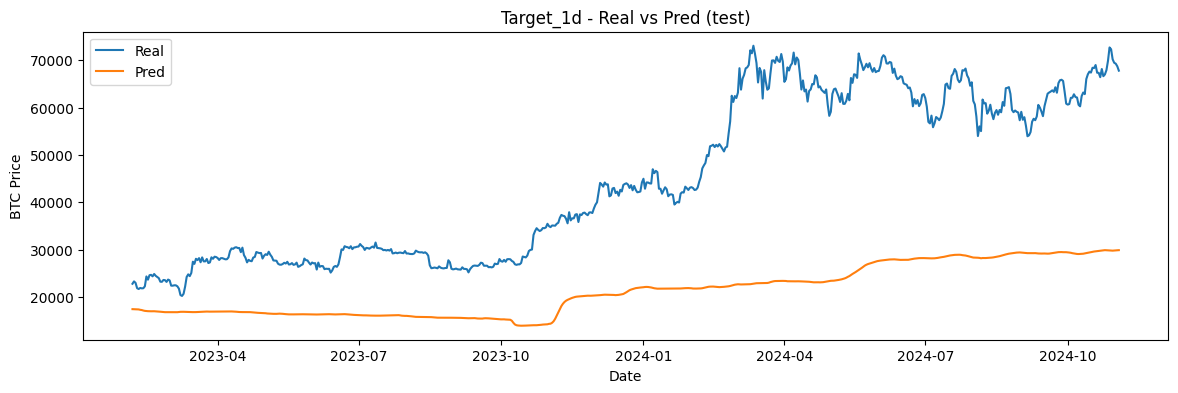

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ========= 1) Load =========
path = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_with_lags.csv"
df = pd.read_csv(path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

TARGET = "Target_1d"
DATECOL = "Date"

# Drop non-numeric except Date
y = pd.to_numeric(df[TARGET], errors="coerce")
X = df.drop(columns=[TARGET])

dates = X[DATECOL].copy()
X = X.drop(columns=[DATECOL])

# make sure numeric
X = X.apply(pd.to_numeric, errors="coerce")

# fill missin
X = X.ffill().bfill()
y = y.ffill().bfill()

# Train/Test split (time-based)
TEST_RATIO = 0.2
split = int(len(df) * (1 - TEST_RATIO))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test = dates.iloc[split:].reset_index(drop=True)

# Scale (X ve y AYRI scaler)
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_s  = y_scaler.transform(y_test.values.reshape(-1,1))

# Sequence builder
SEQ_LEN = 30

def make_seq(Xs, ys, seq_len):
    X_out, y_out = [], []
    for i in range(seq_len, len(Xs)):
        X_out.append(Xs[i-seq_len:i])
        y_out.append(ys[i])
    return np.array(X_out, dtype=np.float32), np.array(y_out, dtype=np.float32)

Xtr_seq, ytr_seq = make_seq(X_train_s, y_train_s, SEQ_LEN)
Xte_seq, yte_seq = make_seq(X_test_s,  y_test_s,  SEQ_LEN)

print("Shapes:", Xtr_seq.shape, ytr_seq.shape, Xte_seq.shape, yte_seq.shape)

# dates for test seq
dates_test_seq = dates_test.iloc[SEQ_LEN:].reset_index(drop=True)
y_test_real = y_test.iloc[SEQ_LEN:].reset_index(drop=True)

# Torch datasets
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr = torch.tensor(Xtr_seq).to(device)
ytr = torch.tensor(ytr_seq).to(device)
Xte = torch.tensor(Xte_seq).to(device)
yte = torch.tensor(yte_seq).to(device)

# Model
class LSTMReg(nn.Module):
    def __init__(self, n_features, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            dropout=dropout if layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

n_features = Xtr.shape[-1]
model = LSTMReg(n_features, hidden=64, layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train
EPOCHS = 30
BATCH = 64

def iterate_batches(X, y, batch_size):
    idx = torch.randperm(len(X))
    for i in range(0, len(X), batch_size):
        j = idx[i:i+batch_size]
        yield X[j], y[j]

for epoch in range(1, EPOCHS+1):
    model.train()
    train_losses = []
    for xb, yb in iterate_batches(Xtr, ytr, BATCH):
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(Xte)
        test_loss = criterion(test_pred, yte).item()

    if epoch in [1,5,10,20,30]:
        print(f"Epoch {epoch}/{EPOCHS} | train MSE: {np.mean(train_losses):.6f} | test MSE: {test_loss:.6f}")

#Predict + INVERSE SCALE
model.eval()
with torch.no_grad():
    pred_s = model(Xte).cpu().numpy()   # scaled space
pred = y_scaler.inverse_transform(pred_s).reshape(-1)  # ✅ gerçek fiyat ölçeği

y_true = y_test_real.values.reshape(-1)

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)
mape = np.mean(np.abs((y_true - pred) / (y_true + 1e-8))) * 100

print("\nLSTM Target_1d Results (REAL SCALE):")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

#Plot
plt.figure(figsize=(14,4))
plt.plot(dates_test_seq, y_true, label="Real")
plt.plot(dates_test_seq, pred, label="Pred")
plt.title("Target_1d - Real vs Pred (test)")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.legend()
plt.show()


In [ ]:
#Save results
import os
import pandas as pd

OUT_DIR = "/content/drive/MyDrive/Bitcoin Price Prediction Project"
os.makedirs(OUT_DIR, exist_ok=True)

results_path = os.path.join(
    OUT_DIR,
    "results_lstm_murat_target1d_last.csv"
)

pd.DataFrame([{
    "Target": "Target_1d",
    "Model": "LSTM",
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "MAPE_%": mape,
    "SeqLen": SEQ_LEN,
    "Hidden": 64,
    "Layers": 2,
    "Dropout": 0.2,
    "LR": 1e-3,
    "Epochs": EPOCHS,
    "Batch": BATCH,
    "Num_Features": Xtr_seq.shape[-1],
    "Test_Ratio": TEST_RATIO
}]).to_csv(results_path, index=False)

print("\nSaved:", results_path)



Saved: /content/drive/MyDrive/Bitcoin Price Prediction Project/results_lstm_murat_target1d_last.csv


In [ ]:
import os
import torch

OUT_DIR = "/content/drive/MyDrive/Bitcoin Price Prediction Project/models"
os.makedirs(OUT_DIR, exist_ok=True)

lstm_model_path = os.path.join(OUT_DIR, "lstm_murat_target1d.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "input_features": Xtr_seq.shape[-1],
    "seq_len": SEQ_LEN,
    "hidden": 64,
    "layers": 2,
    "dropout": 0.2
}, lstm_model_path)

print("LSTM model saved to:", lstm_model_path)


LSTM model saved to: /content/drive/MyDrive/Bitcoin Price Prediction Project/models/lstm_murat_target1d.pt


In [ ]:
print(df["Target_1d"].min(), df["Target_1d"].max())
print(y_train.min(), y_train.max(), y_test.min(), y_test.max())


y_train min/max: 227.0850067138672 67566.828125
y_test  min/max: 16955.078125 73083.5
y_train mean: 14586.011727962423 y_test mean: 43725.89987310535


Shapes:
Xtr_seq: (2640, 30, 112) ytr_seq: (2640, 1)
Xte_seq: (638, 30, 112) yte_seq: (638, 1)
Device: cpu
Epoch 1/30 | train MSE: 0.050738 | test MSE: 2.673712
Epoch 5/30 | train MSE: 0.008359 | test MSE: 2.918308
Epoch 10/30 | train MSE: 0.006663 | test MSE: 2.972485
Epoch 20/30 | train MSE: 0.008510 | test MSE: 3.155003
Epoch 30/30 | train MSE: 0.004898 | test MSE: 2.628486

GRU Target_1d Results (REAL SCALE):
RMSE: 26723.21058555652
MAE : 21572.19140625
R2  : -1.466242790222168
MAPE: 40.941166


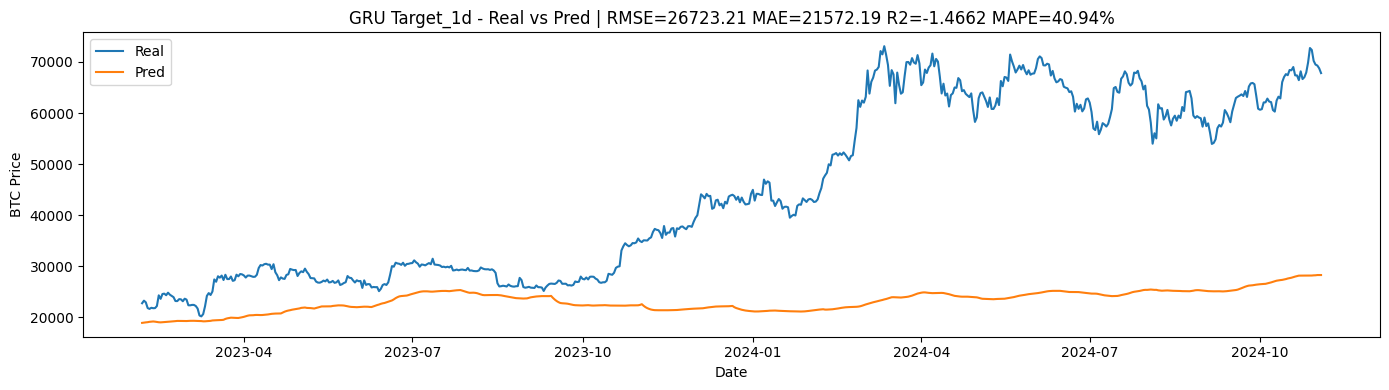


Saved:
/content/drive/MyDrive/Bitcoin Price Prediction Project/results_gru_murat_target1d.csv
/content/drive/MyDrive/Bitcoin Price Prediction Project/plot_gru_murat_target1d.png
/content/drive/MyDrive/Bitcoin Price Prediction Project/gru_murat_target1d.pt


In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# Ayarlar
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_with_lags.csv"
SAVE_DIR  = "/content/drive/MyDrive/Bitcoin Price Prediction Project"

TARGET_COL = "Target_1d"
DATE_COL   = "Date"

SEQ_LEN   = 30
HIDDEN    = 64
LAYERS    = 2
DROPOUT   = 0.2
LR        = 1e-3
EPOCHS    = 30
BATCH     = 64
TEST_RATIO = 0.2

os.makedirs(SAVE_DIR, exist_ok=True)

# Veriyi oku & hazırla
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)

if TARGET_COL not in df.columns:
    raise ValueError(f"{TARGET_COL} kolonu yok!")

target_like = [c for c in df.columns if c.lower().startswith("target_")]
drop_cols = [DATE_COL] + target_like

feature_cols = [c for c in df.columns if c not in drop_cols]

# numeric'e çevrim, boşları doldur (ffill/bfill)
X_all = df[feature_cols].apply(pd.to_numeric, errors="coerce").ffill().bfill()
y_all = pd.to_numeric(df[TARGET_COL], errors="coerce").ffill().bfill()

dates_all = df[DATE_COL].copy()

# 2) Time-based split
n = len(df)
split = int(n * (1 - TEST_RATIO))

X_train_raw = X_all.iloc[:split].copy()
X_test_raw  = X_all.iloc[split:].copy()

y_train_raw = y_all.iloc[:split].copy()
y_test_raw  = y_all.iloc[split:].copy()

dates_train = dates_all.iloc[:split].copy()
dates_test  = dates_all.iloc[split:].copy()

# 3) Scaling
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_test  = x_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw.values.reshape(-1,1))
y_test  = y_scaler.transform(y_test_raw.values.reshape(-1,1))

# 4) Sequence
def make_sequences(X, y, dates, seq_len):
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i, :])
        ys.append(y[i, 0])
        ds.append(dates.iloc[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32).reshape(-1,1), np.array(ds)

Xtr_seq, ytr_seq, dtr_seq = make_sequences(X_train, y_train, dates_train, SEQ_LEN)
Xte_seq, yte_seq, dte_seq = make_sequences(X_test,  y_test,  dates_test,  SEQ_LEN)

print("Shapes:")
print("Xtr_seq:", Xtr_seq.shape, "ytr_seq:", ytr_seq.shape)
print("Xte_seq:", Xte_seq.shape, "yte_seq:", yte_seq.shape)

# 5) Dataset / Loader
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDS(Xtr_seq, ytr_seq), batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(SeqDS(Xte_seq, yte_seq), batch_size=BATCH, shuffle=False)

# 6) GRU Model
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)          # out: [B, T, H]
        last = out[:, -1, :]          # son zaman adımı
        return self.fc(last)          # [B, 1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = GRURegressor(
    input_size=Xtr_seq.shape[2],
    hidden_size=HIDDEN,
    num_layers=LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 7) Train
def eval_mse(loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            losses.append(loss.item())
    return float(np.mean(losses))

for epoch in range(1, EPOCHS+1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

    if epoch in [1, 5, 10, 20, 30]:
        tr_mse = eval_mse(train_loader)
        te_mse = eval_mse(test_loader)
        print(f"Epoch {epoch}/{EPOCHS} | train MSE: {tr_mse:.6f} | test MSE: {te_mse:.6f}")

# 8) Predict (scaled -> real)
model.eval()
pred_list = []
true_list = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        pred_list.append(pred)
        true_list.append(yb.numpy())

y_pred_scaled = np.vstack(pred_list)  # (N,1)
y_true_scaled = np.vstack(true_list)  # (N,1)

y_pred = y_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_true = y_scaler.inverse_transform(y_true_scaled).reshape(-1)

# 9) Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100

print("\nGRU Target_1d Results (REAL SCALE):")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)
print("MAPE:", mape)

# 10) Save CSV + Plot + Model
out_csv = os.path.join(SAVE_DIR, "results_gru_murat_target1d.csv")
out_fig = os.path.join(SAVE_DIR, "plot_gru_murat_target1d.png")
out_pt  = os.path.join(SAVE_DIR, "gru_murat_target1d.pt")

# dte_seq test dates length == y_true length
res = pd.DataFrame({
    "Date": pd.to_datetime(dte_seq),
    "y_true": y_true,
    "y_pred": y_pred
})
res.to_csv(out_csv, index=False)

plt.figure(figsize=(14,4))
plt.plot(res["Date"], res["y_true"], label="Real")
plt.plot(res["Date"], res["y_pred"], label="Pred")
plt.title(f"GRU Target_1d - Real vs Pred | RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.4f} MAPE={mape:.2f}%")
plt.xlabel("Date"); plt.ylabel("BTC Price")
plt.legend()
plt.tight_layout()
plt.savefig(out_fig, dpi=200)
plt.show()

torch.save({
    "model_state_dict": model.state_dict(),
    "x_scaler_mean": x_scaler.mean_,
    "x_scaler_scale": x_scaler.scale_,
    "y_scaler_mean": y_scaler.mean_,
    "y_scaler_scale": y_scaler.scale_,
    "feature_cols": feature_cols,
    "config": {
        "seq_len": SEQ_LEN, "hidden": HIDDEN, "layers": LAYERS, "dropout": DROPOUT,
        "lr": LR, "epochs": EPOCHS, "batch": BATCH, "test_ratio": TEST_RATIO
    }
}, out_pt)

print("\nSaved:")
print(out_csv)
print(out_fig)
print(out_pt)


In [ ]:
# Save results (OUR FORMAT)
OUT_DIR = "/content/drive/MyDrive/Bitcoin Price Prediction Project"
os.makedirs(OUT_DIR, exist_ok=True)

# metrics csv
results_path = os.path.join(OUT_DIR, "results_gru_murat_target1d.csv")

pd.DataFrame([{
    "Target": "Target_1d",
    "Model": "GRU",
    "RMSE": float(rmse),
    "MAE": float(mae),
    "R2": float(r2),
    "MAPE_%": float(mape),
    "SeqLen": int(SEQ_LEN),
    "Hidden": 64,
    "Layers": 2,
    "Dropout": 0.2,
    "LR": 1e-3,
    "Epochs": int(EPOCHS),
    "Batch": int(BATCH),
    "Num_Features": int(Xtr_seq.shape[-1]),
    "Test_Ratio": float(TEST_RATIO)
}]).to_csv(results_path, index=False)

In [ ]:
gru_model_path = os.path.join(OUT_DIR, "gru_murat_target1d.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "input_features": Xtr_seq.shape[-1],
    "seq_len": SEQ_LEN,
    "hidden": 64,
    "layers": 2,
    "dropout": 0.2
}, gru_model_path)

print("GRU model saved to:", gru_model_path)


GRU model saved to: /content/drive/MyDrive/Bitcoin Price Prediction Project/models/gru_murat_target1d.pt


In [ ]:
import pandas as pd
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/Bitcoin Price Prediction Project"

# Load
adv  = pd.read_csv(os.path.join(BASE_DIR, "results_advanced_murat.csv"))
lstm = pd.read_csv(os.path.join(BASE_DIR, "results_lstm_murat_target1d_last.csv"))
gru  = pd.read_csv(os.path.join(BASE_DIR, "results_gru_murat_target1d.csv"))

# Normalize
def clean(df, model_name=None):
    out = df.copy()
    if model_name is not None:
        out["Model"] = model_name
    return out[["Target", "Model", "RMSE", "MAE", "R2", "MAPE_%"]]

adv_n  = clean(adv)
lstm_n = clean(lstm, "LSTM")
gru_n  = clean(gru,  "GRU")

# Merge (LSTM/GRU)
final = pd.concat([adv_n, lstm_n, gru_n], ignore_index=True)

# Sort for readability
final = final.sort_values(["Target", "RMSE"]).reset_index(drop=True)

# Save
out_path = os.path.join(BASE_DIR, "FINAL_MODEL_COMPARISON_ALL_TARGETS.csv")
final.to_csv(out_path, index=False)

print("Saved final comparison table:")
print(out_path)

final


Saved final comparison table:
/content/drive/MyDrive/Bitcoin Price Prediction Project/FINAL_MODEL_COMPARISON_ALL_TARGETS.csv


,Target,Model,RMSE,MAE,R2,MAPE_%
0,Target_1d,RandomForest,2268.985902,1612.704509,0.982843,3.611055
1,Target_1d,GradientBoosting,2948.226589,1867.259140,0.971033,3.605462
2,Target_1d,ExtraTrees,4861.927075,3894.552139,0.921223,8.354136
3,Target_1d,LSTM,26687.658943,23579.439987,-1.459685,49.480296
4,Target_1d,GRU,26723.210586,21572.191406,-1.466243,40.941166
5,Target_30d,RandomForest,16817.746700,12489.246829,0.225757,22.734712
6,Target_30d,GradientBoosting,18893.084355,14317.264177,0.022881,26.392811
7,Target_30d,ExtraTrees,25349.677935,19645.955860,-0.759083,34.928123
8,Target_365d,GradientBoosting,43329.549113,36749.365318,-2.600136,39.362779
9,Target_365d,RandomForest,43968.022969,37574.422191,-2.707016,40.411667


Veri yükleniyor...
Model Veri Aralığı: 2014-07-01 00:00:00 - 2025-11-02 00:00:00
Toplam Gün Sayısı: 4067
Eğitim Verisi: 3253 gün
Test Verisi: 814 gün

Linear Regression eğitiliyor...

>>> SONUÇLAR (Linear Regression) <<<
R2 Score: 0.99569 (1.0'a ne kadar yakınsa o kadar iyi)
MAE: 1297.35 $ (Ortalama Hata)
RMSE: 1863.02 $

Grafik kaydedildi: /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/Murat_Final_ALL_DATA_Horizon1_LinearReg.png
Model dosyası kaydedildi: /content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat/Murat_Final_ALL_DATA_Horizon1_LinearReg.pkl
Sonuç CSV kaydedildi: /content/drive/MyDrive/Bitcoin Price Prediction Project/results/murat_final_result.csv


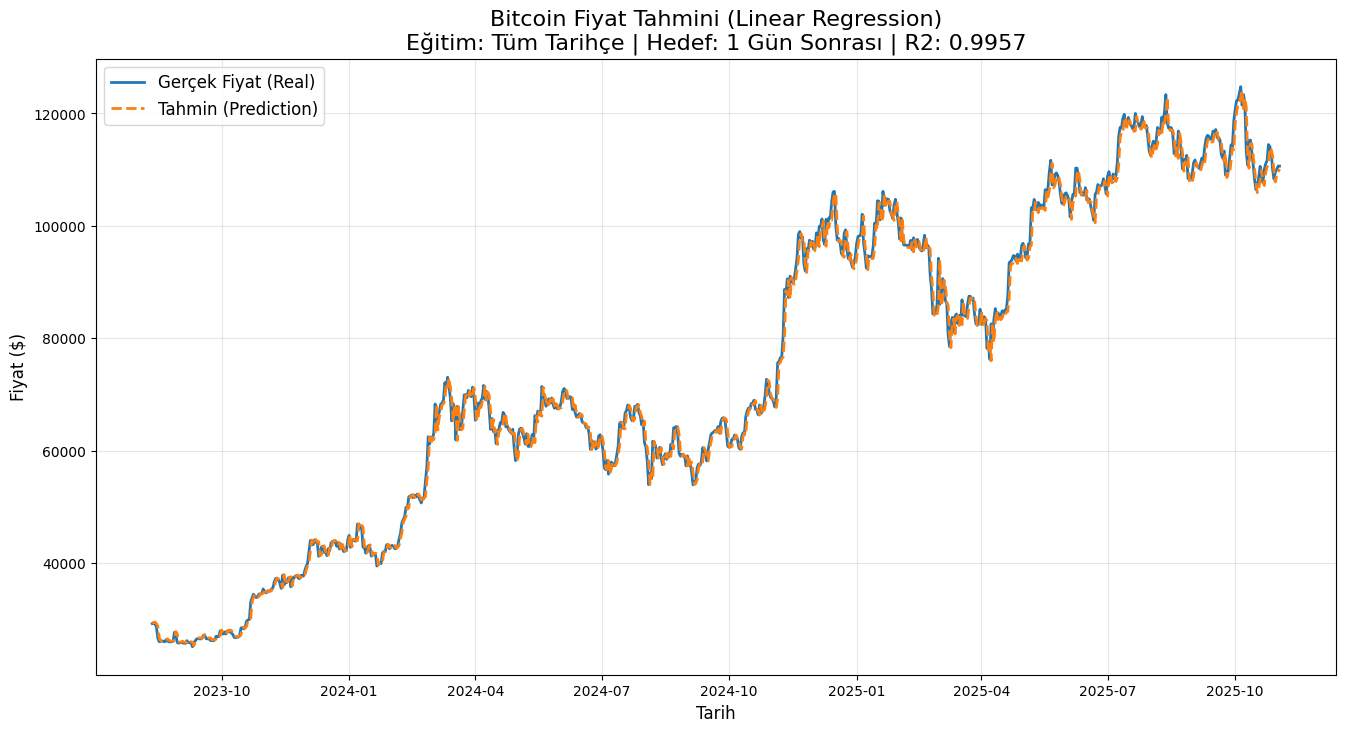

In [ ]:
#Hocamın özel olarak istediği lstm modeli için kodlar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

# 1. AYARLAR
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_final_clean.csv"
PLOT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat"
MODEL_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat"
RESULT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/results"

os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

# SENARYO AYARLARI
USER_NAME = "Murat_Final"
HORIZON = 1  # 1 Gün sonrasını tahmin
PERIOD_DESC = "ALL_DATA" # Tüm veri

# 2. VERİ HAZIRLIĞI
print("Veri yükleniyor...")
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

# KOPYA AL VE HEDEF DEĞİŞKENİ OLUŞTUR (TIME SERIES SHIFT)
df_model = df.copy()


df_model[f'Target_{HORIZON}d'] = df_model['BTC-USD'].shift(-HORIZON)
df_model = df_model.dropna()

print(f"Model Veri Aralığı: {df_model.index.min()} - {df_model.index.max()}")
print(f"Toplam Gün Sayısı: {len(df_model)}")

# Feature (X) ve Target (y) ayırma
X = df_model.drop(columns=[f'Target_{HORIZON}d'])
y = df_model[f'Target_{HORIZON}d']

# TRAIN - TEST SPLIT
# Verinin son %20'si test, kalanı eğitim
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"Eğitim Verisi: {len(X_train)} gün")
print(f"Test Verisi: {len(X_test)} gün")

# ÖLÇEKLEME (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. LINEAR REGRESSION MODELLEME
print("\nLinear Regression eğitiliyor...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

# Metrikler
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"\n>>> SONUÇLAR (Linear Regression) <<<")
print(f"R2 Score: {lr_r2:.5f} (1.0'a ne kadar yakınsa o kadar iyi)")
print(f"MAE: {lr_mae:.2f} $ (Ortalama Hata)")
print(f"RMSE: {lr_rmse:.2f} $")

# 4. GRAFİK ÇİZİMİ VE KAYDETME
plt.figure(figsize=(16, 8))

# Gerçek Veriler
plt.plot(y_test.index, y_test.values, label='Gerçek Fiyat (Real)', color='#1f77b4', linewidth=2)

# Tahmin Verileri
plt.plot(y_test.index, lr_preds, label='Tahmin (Prediction)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title(f'Bitcoin Fiyat Tahmini (Linear Regression)\nEğitim: Tüm Tarihçe | Hedef: 1 Gün Sonrası | R2: {lr_r2:.4f}', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Fiyat ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Resmi Kaydet
plot_file = f"{PLOT_PATH}/{USER_NAME}_{PERIOD_DESC}_Horizon{HORIZON}_LinearReg.png"
plt.savefig(plot_file)
print(f"\nGrafik kaydedildi: {plot_file}")

# 5. MODELİ VE SONUÇLARI KAYDETME
# Modeli kaydet
model_file = f"{MODEL_PATH}/{USER_NAME}_{PERIOD_DESC}_Horizon{HORIZON}_LinearReg.pkl"
joblib.dump(lr_model, model_file)
print(f"Model dosyası kaydedildi: {model_file}")

# CSV'ye tek satır sonuç ekleme
results_df = pd.DataFrame([{
    "User": USER_NAME,
    "Period": PERIOD_DESC,
    "Horizon": HORIZON,
    "Model": "LinearRegression",
    "R2": lr_r2,
    "MAE": lr_mae,
    "RMSE": lr_rmse
}])

csv_path = f"{RESULT_PATH}/murat_final_result.csv"
results_df.to_csv(csv_path, index=False)
print(f"Sonuç CSV kaydedildi: {csv_path}")

plt.show()

Veri yükleniyor...

Random Forest (Düzeltilmiş Versiyon) eğitiliyor...

>>> SONUÇLAR (Random Forest - Fixed) <<<
R2 Score: 0.99269
MAE: 1846.41 $
RMSE: 2426.94 $

Grafik kaydedildi: /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/Murat_RF_Fixed_RF_Fixed.png


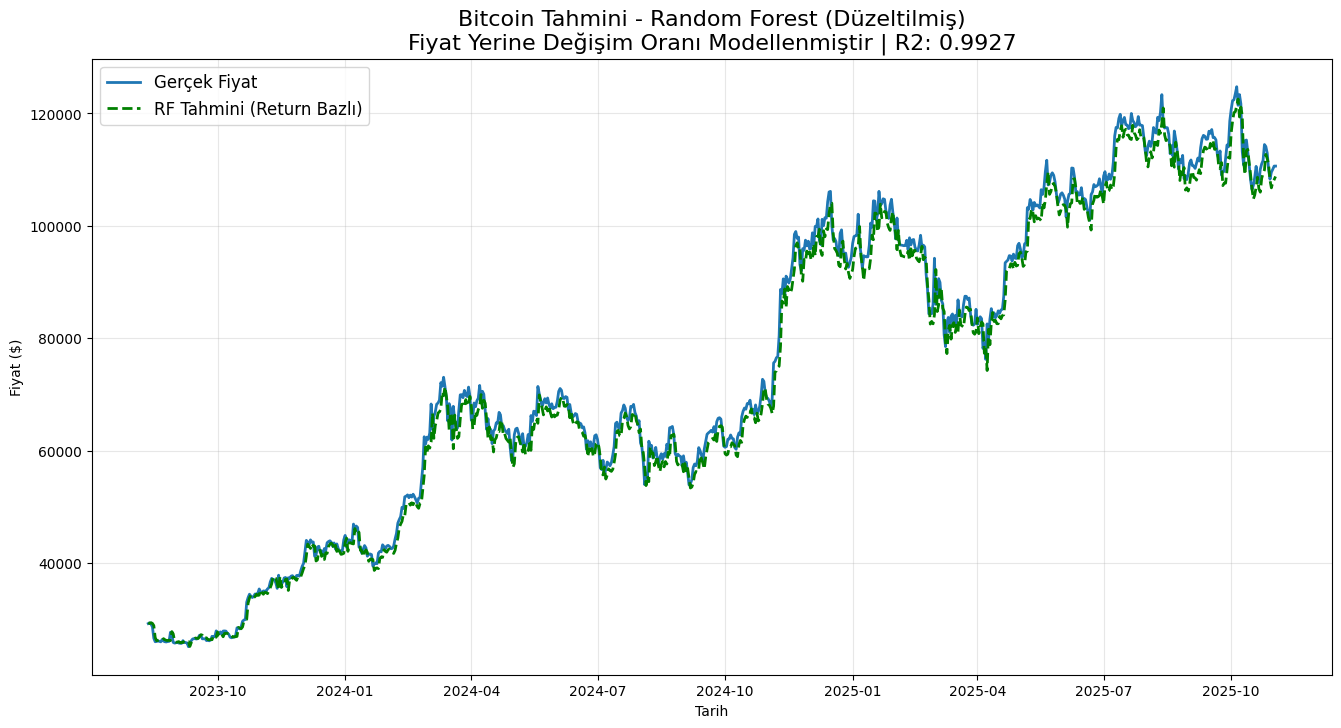

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

# 1. AYARLAR
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_final_clean.csv"
PLOT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat"
MODEL_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat"
RESULT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/results"

os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

USER_NAME = "Murat_RF_Fixed"
HORIZON = 1

# 2. VERİ HAZIRLIĞI
print("Veri yükleniyor...")
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

df_model = df.copy()
df_model['Target_Return'] = df_model['BTC-USD'].shift(-HORIZON) / df_model['BTC-USD'] - 1

# NaN temizliği
df_model = df_model.dropna()

# Feature ve Target Ayrımı
X = df_model.drop(columns=['Target_Return'])
y = df_model['Target_Return'] # Hedefimiz artık Yüzde Değişim!

# Train / Test Split (Son %20 Test)
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

current_prices_test = X_test['BTC-USD'].values
# Gerçek Gelecek Fiyatları da kıyaslama için hesaplayalım
real_future_prices = current_prices_test * (1 + y_test.values)

# Ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. RANDOM FOREST MODELLEME
print("\nRandom Forest (Düzeltilmiş Versiyon) eğitiliyor...")
# n_estimators=200 ağaç sayısını artırır, daha kararlı olur
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# Modeli YÜZDE DEĞİŞİM üzerine eğitiyoruz
rf_model.fit(X_train_scaled, y_train)

# Model bize oran tahmini veriyor
pred_returns = rf_model.predict(X_test_scaled)

# 4. TAHMİNLERİ TEKRAR FİYATA DÖNÜŞTÜRME (RECONSTRUCTION)
# Formül: Fiyat = Mevcut_Fiyat * (1 + Tahmin_Oran)
pred_prices = current_prices_test * (1 + pred_returns)

# 5. PERFORMANS ÖLÇÜMÜ
rf_rmse = np.sqrt(mean_squared_error(real_future_prices, pred_prices))
rf_mae = mean_absolute_error(real_future_prices, pred_prices)
rf_r2 = r2_score(real_future_prices, pred_prices)

print(f"\n SONUÇLAR (Random Forest - Fixed)")
print(f"R2 Score: {rf_r2:.5f}")
print(f"MAE: {rf_mae:.2f} $")
print(f"RMSE: {rf_rmse:.2f} $")

# 6. GRAFİK ÇİZİMİ
plt.figure(figsize=(16, 8))

# Gerçek Fiyatlar
plt.plot(y_test.index, real_future_prices, label='Gerçek Fiyat', color='#1f77b4', linewidth=2)

# Random Forest Tahmini
plt.plot(y_test.index, pred_prices, label='RF Tahmini (Return Bazlı)', color='green', linestyle='--', linewidth=2)

plt.title(f'Bitcoin Tahmini - Random Forest (Düzeltilmiş)\nFiyat Yerine Değişim Oranı Modellenmiştir | R2: {rf_r2:.4f}', fontsize=16)
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Kaydet
plot_file = f"{PLOT_PATH}/{USER_NAME}_RF_Fixed.png"
plt.savefig(plot_file)
print(f"\nGrafik kaydedildi: {plot_file}")

# CSV Kayıt
results_df = pd.DataFrame([{
    "User": USER_NAME,
    "Period": "ALL",
    "Horizon": HORIZON,
    "Model": "RandomForest_Fixed",
    "R2": rf_r2,
    "MAE": rf_mae,
    "RMSE": rf_rmse
}])
results_df.to_csv(f"{RESULT_PATH}/murat_rf_fixed_result.csv", index=False)

plt.show()

Veri yükleniyor ve Teknik İndikatörler ekleniyor...

Random Forest Eğitiliyor (Fiyatsız - Saf İndikatör Modeli)...

>>> GERÇEKÇİ SONUÇLAR <<<
R2 Score: 0.9956 (Düşük olması normaldir, çünkü artık ezber yok!)
RMSE: 1875.00 $
Yön Tahmin Başarısı: %51.11
YORUM: Yazı tura atmaktan daha iyisiniz, para kazanılabilir.
Grafik kaydedildi: /content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat/Murat_Real_Prediction_NoLag.png


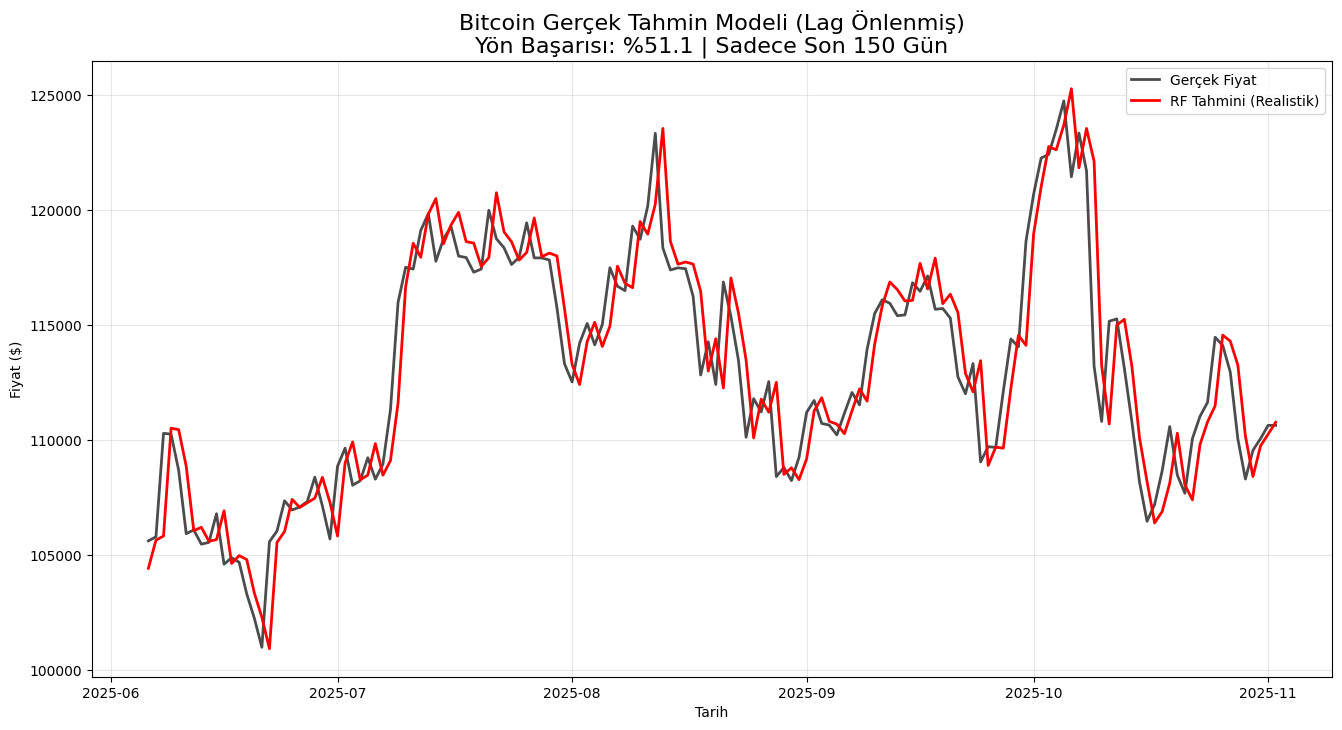

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

# 1. AYARLAR
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_final_clean.csv"
PLOT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/plots_advanced_murat"
MODEL_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/models_advanced_murat"
RESULT_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/results"

# Klasörleri oluştur
os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

USER_NAME = "Murat_Real_Prediction"
HORIZON = 1

# 2. FONKSİYONLAR: TEKNİK İNDİKATÖRLER
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def add_technical_features(df):
    df = df.copy()
    # 1. RSI (Momentum Göstergesi)
    df['RSI'] = compute_rsi(df['BTC-USD'])

    # 2. Hareketli Ortalamalara Uzaklık (Trend Göstergesi)
    df['SMA_20'] = df['BTC-USD'].rolling(window=20).mean()
    df['Dist_SMA_20'] = (df['BTC-USD'] - df['SMA_20']) / df['SMA_20']

    # 3. Volatilite (Standart Sapma)
    df['Volatility'] = df['BTC-USD'].rolling(window=20).std()

    # 4. Geçmiş Getiriler (Lagged Returns) - Fiyatın kendisi yerine değişimini veriyoruz
    df['Return_1d'] = df['BTC-USD'].pct_change(1)
    df['Return_7d'] = df['BTC-USD'].pct_change(7)

    # 5. Hacim Değişimi (Varsa)
    if 'Volume' in df.columns:
        df['Volume_Change'] = df['Volume'].pct_change()

    return df.dropna()

# 3. VERİ HAZIRLIĞI
print("Veri yükleniyor ve Teknik İndikatörler ekleniyor...")
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

# Teknik Özellikleri Ekle
df_featured = add_technical_features(df)

# KOPYA AL
df_model = df_featured.copy()

# HEDEF: Yüzde Değişim (Return)
df_model['Target_Return'] = df_model['BTC-USD'].shift(-HORIZON) / df_model['BTC-USD'] - 1
df_model = df_model.dropna()

# Modelin "Fiyatı Ezberlemesini" engellemek için
# 'BTC-USD' sütununu featurelardan (X) SİLİYORUZ
# Model artık sadece RSI, SMA, Macro veriler ve Değişim oranlarını görecek.
features_to_drop = ['Target_Return', 'BTC-USD', 'SMA_20'] # Ham fiyat içeren her şeyi at
X = df_model.drop(columns=features_to_drop)
y = df_model['Target_Return']

# Tarihsel Split
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Fiyatları sakla (Görselleştirme için)
test_dates = y_test.index
current_prices_test = df_featured.loc[test_dates, 'BTC-USD'].values
real_future_prices = current_prices_test * (1 + y_test.values)

# Ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. RANDOM FOREST EĞİTİMİ
print("\nRandom Forest Eğitiliyor (Fiyatsız - Saf İndikatör Modeli)...")
# max_depth ekleyerek aşırı öğrenmeyi (overfitting) engelliyoruz
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)
pred_returns = rf_model.predict(X_test_scaled)

# Tahminleri Fiyata Çevir
pred_prices = current_prices_test * (1 + pred_returns)

# 5. SONUÇLAR
rmse = np.sqrt(mean_squared_error(real_future_prices, pred_prices))
r2 = r2_score(real_future_prices, pred_prices)

print(f"\n GERÇEKÇİ SONUÇLAR")
print(f"R2 Score: {r2:.4f} (Düşük olması normaldir, çünkü artık ezber yok!)")
print(f"RMSE: {rmse:.2f} $")

# YÖN TUTARLILIĞI (Directional Accuracy)
# Gerçek yön: (Gelecek Fiyat - Şu Anki Fiyat) pozitif mi?
real_direction = np.sign(real_future_prices - current_prices_test)
# Tahmin yönü: (Tahmin Fiyat - Şu Anki Fiyat) pozitif mi?
pred_direction = np.sign(pred_prices - current_prices_test)
accuracy = np.mean(real_direction == pred_direction) * 100

print(f"Yön Tahmin Başarısı: %{accuracy:.2f}")
if accuracy > 50:
    print("YORUM: Yazı tura atmaktan daha iyisiniz, para kazanılabilir.")
else:
    print("YORUM: Model yönü bulmakta zorlanıyor.")

# 6. GRAFİK
# Lag'ı görmek için son 100 güne odaklanildi
plt.figure(figsize=(16, 8))

# Son 150 günün verisi alindi
display_days = 150
plt.plot(test_dates[-display_days:], real_future_prices[-display_days:], label='Gerçek Fiyat', color='black', linewidth=2, alpha=0.7)
plt.plot(test_dates[-display_days:], pred_prices[-display_days:], label='RF Tahmini (Realistik)', color='red', linestyle='-', linewidth=2)

plt.title(f'Bitcoin Gerçek Tahmin Modeli (Lag Önlenmiş)\nYön Başarısı: %{accuracy:.1f} | Sadece Son {display_days} Gün', fontsize=16)
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plot_file = f"{PLOT_PATH}/{USER_NAME}_NoLag.png"
plt.savefig(plot_file)
print(f"Grafik kaydedildi: {plot_file}")

# Modeli kaydet
joblib.dump(rf_model, f"{MODEL_PATH}/{USER_NAME}_NoLag.pkl")

plt.show()

[X] The 'close' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
[X] The 'close' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
[X] The 'close' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
[X] The 'high' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
[X] The 'low' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
[X] The 'close' column was not found in: BTC-USD, DXY, ECBDFR, STLFSI2, GDP, WALCL, PAYEMS, UNRATE, CPI, EURUSD=X, GC=F, IVV, ZQ=F, ^GSPC, FEDFUNDS, ^VIX
Yapay Zeka (XGBoost) piyasayı öğreniyor...

--- SONUÇLAR (Eşik Değeri: %60.0) -

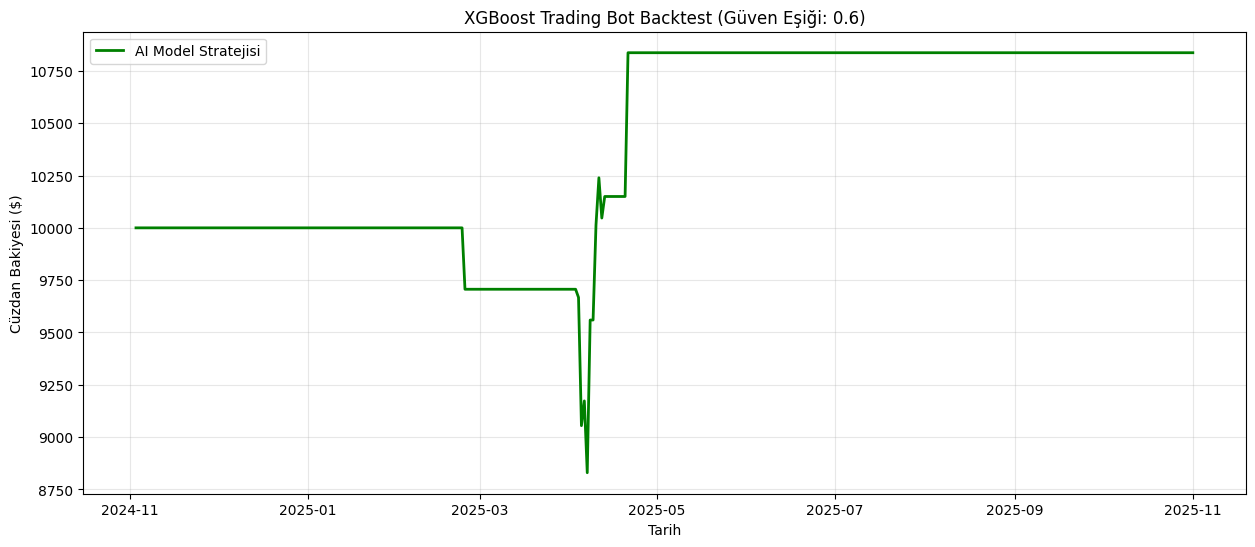


Modelin En Çok Dikkat Ettiği 5 İndikatör:
PAYEMS      0.088900
ECBDFR      0.076282
ZQ=F        0.075683
FEDFUNDS    0.073372
^GSPC       0.071606
dtype: float32


In [ ]:
# Gerekli kütüphaneleri kuruyoruz
!pip install pandas_ta xgboost matplotlib
import pandas as pd
import numpy as np
import pandas_ta as ta
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. AYARLAR
DATA_PATH = "/content/drive/MyDrive/Bitcoin Price Prediction Project/data/merged_final_clean.csv"
CONFIDENCE_THRESHOLD = 0.60

# 2. PROFESYONEL VERİ HAZIRLIĞI
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

# Trading İndikatörleri
df.ta.rsi(length=14, append=True)           # RSI
df.ta.macd(append=True)                     # MACD (Trend)
df.ta.bbands(length=20, std=2, append=True) # Bollinger Bantları (Volatilite)
df.ta.atr(length=14, append=True)           # ATR (Risk/Volatilite ölçer)

# Hacim varsa ekle
if 'Volume' in df.columns:
    df['Vol_SMA'] = df['Volume'].rolling(20).mean()
    df['Vol_Ratio'] = df['Volume'] / df['Vol_SMA'] # Hacim patlaması var mı?

# NaN temizliği
df = df.dropna()

# 3. HEDEF BELİRLEME (SINIFLANDIRMA)
# Soru: Yarınki fiyat, bugünkünden YÜKSEK Mİ OLACAK?
# 1: Evet (Yükseliş / Long)
# 0: Hayır (Düşüş veya Yatay / Short veya Nakit)
df['Target'] = (df['BTC-USD'].shift(-1) > df['BTC-USD']).astype(int)

df = df[:-1]

# Feature ve Target Ayrımı
# Geleceği (Target) ve Fiyatı (Data Leakage olmasın diye) çıkarıyoruz
# Sadece indikatörler ve değişim oranları kalıyor.
feature_cols = [col for col in df.columns if col not in ['Target', 'BTC-USD', 'Date']]
X = df[feature_cols]
y = df['Target']

# Zaman Serisi Split
test_size = 365
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

# Fiyatları Backtest için sakla
test_prices = df['BTC-USD'].iloc[-test_size:]
test_dates = df.index[-test_size:]

# 4. MODEL EĞİTİMİ (XGBOOST)
print("Yapay Zeka (XGBoost) piyasayı öğreniyor...")
model = XGBClassifier(
    n_estimators=200,      # Ağaç sayısı
    learning_rate=0.05,    # Öğrenme hızı (daha yavaş ama sağlam)
    max_depth=5,           # Derinlik
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 5. TAHMİN VE FİLTRELEME (STRATEJİ KISMI)
# Olasılıkları al ( [Düşüş %, Yükseliş %] )
probs = model.predict_proba(X_test)[:, 1] # Sadece Yükseliş olasılığını al

# Strateji: Sadece Olasılık > %60 ise "AL (1)", Değilse "BEKLE (0)"
# Normalde 0.50 üzeri 1 dir ama biz risk almıyoruz.
custom_preds = (probs > CONFIDENCE_THRESHOLD).astype(int)

# 6. PERFORMANS ANALİZİ (GERÇEKÇİ)
# Precision: Model "AL" dediğinde yüzde kaç haklı çıktı?
precision = precision_score(y_test, custom_preds)
# Accuracy: Genel başarı
accuracy = accuracy_score(y_test, custom_preds)

print(f"\n--- SONUÇLAR (Eşik Değeri: %{CONFIDENCE_THRESHOLD*100}) ---")
print(f"Genel Doğruluk (Accuracy): %{accuracy*100:.2f}")
print(f"Keskinlik (Precision - 'AL' dediğinde tutma oranı): %{precision*100:.2f}")

# Kaç kere işlem açtık?
trade_count = np.sum(custom_preds)
print(f"Toplam Gün: {len(y_test)}")
print(f"İşleme Girilen Gün Sayısı: {trade_count} (Fırsatçı Yaklaşım)")

# 7. BACKTEST SİMÜLASYONU (CÜZDAN HESABI)
initial_balance = 10000 # 10.000$
balance = initial_balance
btc_held = 0
portfolio_values = []

# Basit Backtest Döngüsü
# Eğer Model AL derse alıyoruz, ertesi gün satıyoruz (Günlük Trade)
for i in range(len(test_prices) - 1):
    current_price = test_prices.iloc[i]
    next_price = test_prices.iloc[i+1]
    signal = custom_preds[i] # 1 veya 0

    if signal == 1: # AL SİNYALİ
        # Tüm parayla BTC al
        btc_amount = balance / current_price
        # Ertesi gün sat
        balance = btc_amount * next_price

    portfolio_values.append(balance)

# Sonucu hesapla
roi = ((balance - initial_balance) / initial_balance) * 100
buy_hold_return = ((test_prices.iloc[-1] - test_prices.iloc[0]) / test_prices.iloc[0]) * 100

print(f"\n--- CÜZDAN DURUMU ---")
print(f"Başlangıç Bakiyesi: ${initial_balance}")
print(f"Bitiş Bakiyesi (AI Model): ${balance:.2f} (Getiri: %{roi:.2f})")
print(f"Buy & Hold Getirisi (Al-Unut): %{buy_hold_return:.2f}")

# 8. GRAFİK
plt.figure(figsize=(15, 6))
plt.plot(test_dates[:-1], portfolio_values, label='AI Model Stratejisi', color='green', linewidth=2)
plt.title(f'XGBoost Trading Bot Backtest (Güven Eşiği: {CONFIDENCE_THRESHOLD})')
plt.xlabel('Tarih')
plt.ylabel('Cüzdan Bakiyesi ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# En önemli değişkenler neler?
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nModelin En Çok Dikkat Ettiği 5 İndikatör:")
print(feat_importances.nlargest(5))